# Working with complicated dataset

Your name: Karla Nguyen (017111185)

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [28]:
# Import libraries
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
### Your code here . . .

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

fields = [
    "query acc.ver", "subject acc.ver", "% identity", "alignment length",
    "mismatches", "gap opens", "q. start", "q. end", "s. start", "s. end",
    "evalue", "bit score", "% positives", "bonds", "publications"
]

df = pd.read_csv(url, comment='#', names=fields, usecols=range(15))

df = df.drop(columns=['query acc.ver']).set_index('subject acc.ver')

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41


### Question 2
What is the average number of publications?

In [30]:
### Your code here . . .
avg_pubs = pd.to_numeric(df['publications'], errors='coerce').mean()
print(f"Average number of publications: {avg_pubs:.2f}")

Average number of publications: 26.99


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [31]:
### Your code here . . .
bonds_clean = df['bonds'].str.replace(',', '').str.strip()
df['bonds_numeric'] = pd.to_numeric(bonds_clean, errors='coerce')

df_filtered = df.dropna(subset=['bonds_numeric'])

result = df_filtered[df_filtered["bonds_numeric"] > 15000].index.tolist()

print(result)

['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1', '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1', 'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1', 'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1', 'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1', 'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1', 'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1', 'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1', 'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1']


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

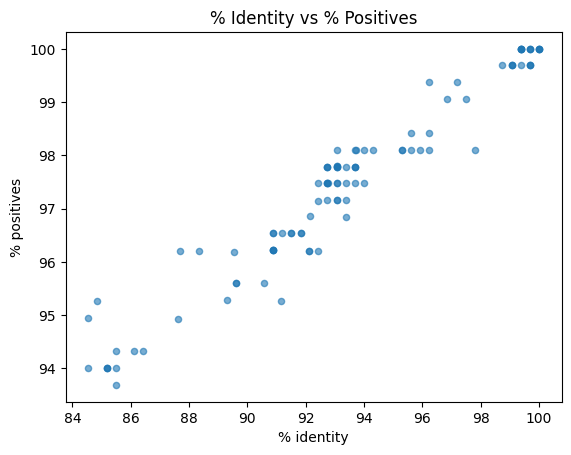

In [32]:
### Your code here . . .
import matplotlib.pyplot as plt

df.plot.scatter(x='% identity', y='% positives',
                title='% Identity vs % Positives',
                alpha=0.6)
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [33]:
### Your code here . . .
url_source = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
df_source = pd.read_csv(url_source)

df_source = df_source.rename(columns={'Source': 'Protein source'})

df_final = df.merge(df_source[['Protein', 'Protein source']],
                    left_index=True,
                    right_on='Protein',
                    how='left')

df_final['Protein source'] = df_final['Protein source'].fillna('NA')
df_final = df_final.set_index('Protein')
df_final.index.name = 'subject acc.ver'

df_final.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,bonds_numeric,Protein source
subject acc.ver,,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NA
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9,1487.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47,17947.0,NA
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13,12106.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41,2319.0,NA
